<a href="https://colab.research.google.com/github/kyungeunvoyage/NailFoldExp/blob/main/Analysis/(Analysis)Force_Discrimination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 스타일 설정
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

In [20]:
import pandas as pd

# 1. 데이터 로드 로직
file_names = ['P1_ForceDiscrimination.csv', 'P2_ForceDiscrimination.csv']
data_list = []

for file in file_names:
    try:
        # CSV 로드
        temp_df = pd.read_csv(file)

        # 새로운 CSV 구조 반영: IsCorrect 대신 ChoseComparison 컬럼 사용
        target_col = 'ChoseComparison'

        if target_col in temp_df.columns:
            # 데이터 타입이 문자열(object)인 경우 처리 (true/false 또는 '1'/'0')
            if temp_df[target_col].dtype == 'object':
                temp_df[target_col] = temp_df[target_col].str.lower().map({
                    'true': 1, 'false': 0,
                    '1': 1, '0': 0
                })

            # 정수형으로 변환 (결측치가 없을 경우)
            temp_df[target_col] = temp_df[target_col].fillna(0).astype(int)

        data_list.append(temp_df)
        print(f"성공적으로 로드함: {file} ({len(temp_df)}행)")

    except FileNotFoundError:
        print(f"파일을 찾을 수 없습니다: {file}")
    except Exception as e:
        print(f"{file} 처리 중 오류 발생: {e}")

# 데이터 통합 (필요한 경우)
if data_list:
    df = pd.concat(data_list, ignore_index=True)

성공적으로 로드함: P1_ForceDiscrimination.csv (40행)
성공적으로 로드함: P2_ForceDiscrimination.csv (40행)


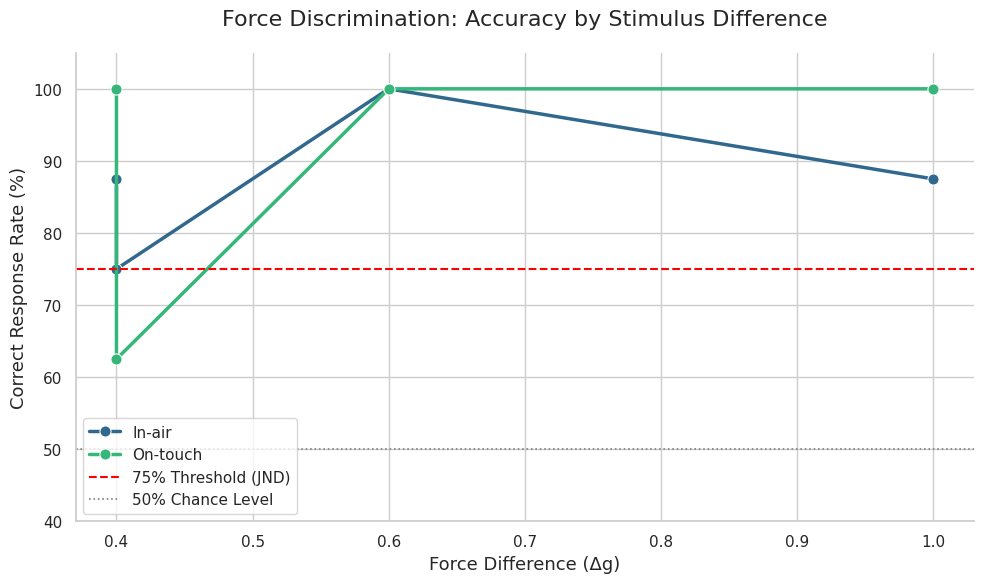

### Overall Accuracy by Condition (%) ###
Condition
In-air      90.0
On-touch    92.5
Name: IsCorrect_Num, dtype: float64


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 통합 (이전 단계에서 생성된 data_list 사용)
# 만약 코드를 따로 실행하신다면 df = pd.read_csv('파일이름.csv')를 사용하세요.
df = pd.concat(data_list, ignore_index=True)

# 2. 정답 여부(IsCorrect) 계산 로직 추가
# 2AFC 실험에서 '정답'이란 더 강한 자극을 선택하는 것입니다.
def check_correct(row):
    # 비교 자극(Comp)이 기준 자극(Ref)보다 큰 경우 -> 비교 자극을 선택(1)해야 정답
    if row['Comparison'] > row['Reference']:
        return 1 if row['ChoseComparison'] == 1 else 0
    # 비교 자극(Comp)이 기준 자극(Ref)보다 작은 경우 -> 기준 자극을 선택(0)해야 정답
    elif row['Comparison'] < row['Reference']:
        return 1 if row['ChoseComparison'] == 0 else 0
    # 자극이 같은 경우 (1.0 vs 1.0) -> 어느 쪽을 골라도 정답률 계산에서는 0.5(우연)로 처리하거나 제외할 수 있음
    else:
        return 1 if row['UserChoice'] is not None else 0 # 여기서는 응답 여부만 확인

df['IsCorrect_Num'] = df.apply(check_correct, axis=1)

# 3. 자극 간의 '힘의 차이(Force Difference, Δg)' 계산
# 새로운 CSV는 이미 숫자이므로 .replace('g', '') 과정이 필요 없습니다.
df['ForceDiff'] = abs(df['Comparison'] - df['Reference'])

# 4. 조건별/자극차이별 정답률 계산
# 자극 차이가 0인 경우는 JND 계산에서 제외하는 것이 일반적이므로 필터링할 수 있습니다.
analysis_df = df[df['ForceDiff'] > 0].copy()

accuracy_summary = analysis_df.groupby(['Condition', 'ForceDiff'])['IsCorrect_Num'].mean().reset_index()
accuracy_summary['Accuracy_Pct'] = accuracy_summary['IsCorrect_Num'] * 100

# 5. 시각화 (Psychometric Curve)
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 선 그래프
sns.lineplot(data=accuracy_summary, x='ForceDiff', y='Accuracy_Pct', hue='Condition',
             marker='o', markersize=8, linewidth=2.5, palette='viridis')

# 75% Threshold 가이드라인 (JND 기준점)
plt.axhline(75, color='red', linestyle='--', linewidth=1.5, label='75% Threshold (JND)')
# 50% Chance Level (무작위 선택 수준)
plt.axhline(50, color='gray', linestyle=':', linewidth=1.2, label='50% Chance Level')

# 그래프 디테일 설정
plt.title('Force Discrimination: Accuracy by Stimulus Difference', fontsize=16, pad=20)
plt.xlabel('Force Difference (Δg)', fontsize=13)
plt.ylabel('Correct Response Rate (%)', fontsize=13)
plt.ylim(40, 105)
plt.legend(frameon=True)
sns.despine()

plt.tight_layout()
plt.show()

# 6. 통계 요약 출력
overall_acc = df.groupby('Condition')['IsCorrect_Num'].mean() * 100
print("### Overall Accuracy by Condition (%) ###")
print(overall_acc)

# 가상 데이터 plotting


<>:95: SyntaxWarning: invalid escape sequence '\D'
<>:95: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2461/904726032.py:95: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('Force Difference ($\Delta$g) [Comparison - Reference]', fontsize=14)


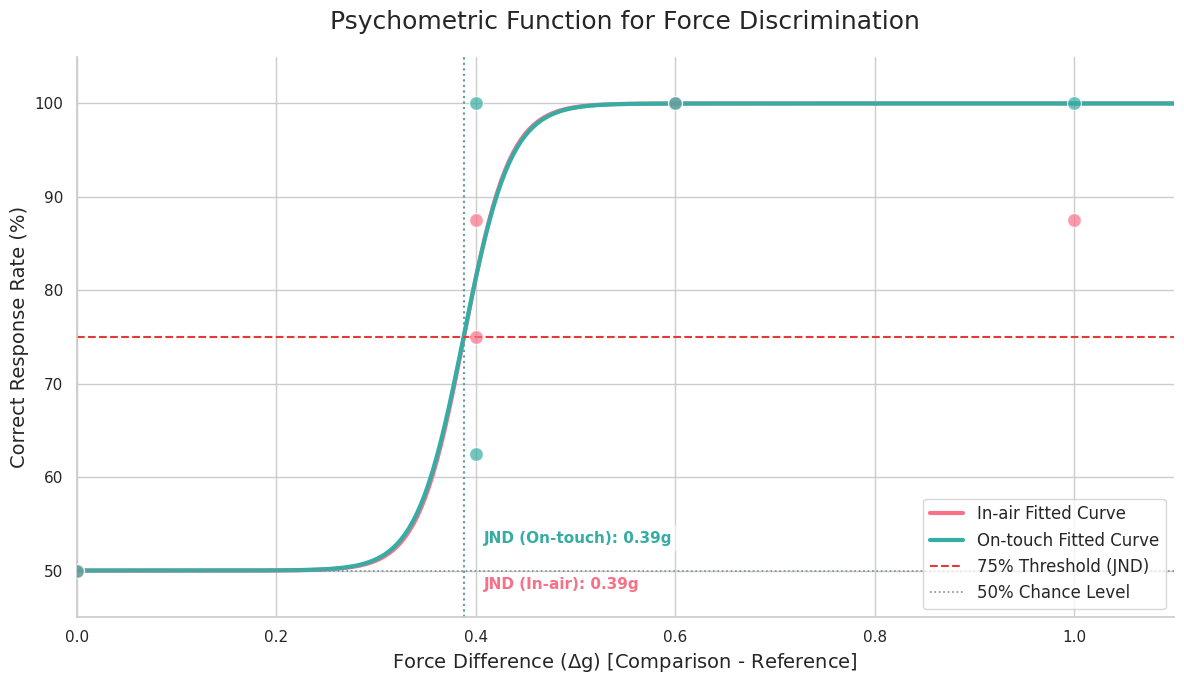

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import expit

# 1. 데이터 로드 및 통합
file_names = ['P1_ForceDiscrimination.csv', 'P2_ForceDiscrimination.csv']
data_list = []

for file in file_names:
    try:
        temp_df = pd.read_csv(file)
        data_list.append(temp_df)
    except FileNotFoundError:
        print(f"파일을 찾을 수 없습니다: {file}")

if not data_list:
    print("데이터가 없습니다. 파일명을 확인해주세요.")
else:
    df = pd.concat(data_list, ignore_index=True)

    # --- 핵심 수정: 정답(IsCorrect) 판별 로직 ---
    def calculate_correct(row):
        # Comparison이 Reference보다 큰 경우: Comparison을 선택(1)해야 정답
        if row['Comparison'] > row['Reference']:
            return 1 if row['ChoseComparison'] == 1 else 0
        # Comparison이 Reference보다 작은 경우: Reference를 선택(0)해야 정답
        elif row['Comparison'] < row['Reference']:
            return 1 if row['ChoseComparison'] == 0 else 0
        # 두 자극이 같은 경우 (1.0 vs 1.0): 확률적으로 0.5로 처리됨
        else:
            return 0.5

    df['IsCorrect_Num'] = df.apply(calculate_correct, axis=1)

    # 자극 간의 '힘의 차이(Force Difference)' 계산 (이미 숫자형이므로 단순 뺄셈)
    df['ForceDiff'] = abs(df['Comparison'] - df['Reference'])

    # 2. S자 곡선(Sigmoid) 모델 정의
    # 0.5(우연)에서 1.0(완벽) 사이를 오가는 로지스틱 함수
    # 이 모델에서 x0는 정확히 75% 정답률(JND) 지점이 됩니다.
    def logistic_model(x, k, x0):
        return 0.5 + 0.5 * expit(k * (x - x0))

    # 3. 시각화 설정
    plt.figure(figsize=(12, 7))
    sns.set_theme(style="whitegrid")

    # 실제 데이터에 존재하는 조건 자동 탐색 (In-air, On-touch 등)
    available_conditions = df['Condition'].unique()
    colors = sns.color_palette("husl", len(available_conditions))

    x_smooth = np.linspace(0, max(df['ForceDiff']) + 0.2, 300)

    for i, cond in enumerate(available_conditions):
        cond_data = df[df['Condition'] == cond]
        if cond_data.empty: continue

        # 강도 차이(ForceDiff)별 평균 정답률 계산
        fit_data = cond_data.groupby('ForceDiff')['IsCorrect_Num'].mean().reset_index()

        # (0, 0.5) 가상 데이터를 추가하여 심리물리학적 일관성 확보
        X_fit = np.insert(fit_data['ForceDiff'].values, 0, 0.0)
        Y_fit = np.insert(fit_data['IsCorrect_Num'].values, 0, 0.5)

        try:
            # 커브 피팅 수행 (기울기 k, 75% 지점 x0)
            popt, _ = curve_fit(logistic_model, X_fit, Y_fit, p0=[10, 0.4], bounds=([0, 0], [50, 2.0]))
            k_fit, x0_fit = popt

            # 피팅 곡선 그리기
            y_smooth = logistic_model(x_smooth, k_fit, x0_fit) * 100
            plt.plot(x_smooth, y_smooth, color=colors[i], linewidth=3, label=f'{cond} Fitted Curve')

            # 실제 데이터 포인트 표시
            plt.scatter(fit_data['ForceDiff'], fit_data['IsCorrect_Num'] * 100,
                        color=colors[i], s=100, alpha=0.7, edgecolor='white', zorder=5)

            # JND (75% Threshold) 표시
            jnd_val = x0_fit
            plt.axvline(jnd_val, color=colors[i], linestyle=':', alpha=0.8)
            plt.text(jnd_val + 0.02, 48 + (i*5), f'JND ({cond}): {jnd_val:.2f}g',
                     color=colors[i], fontsize=11, fontweight='bold', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

        except Exception as e:
            print(f"{cond} 피팅 실패: {e}")

    # 4. 가이드라인 및 그래프 디테일
    plt.axhline(75, color='#E53935', linestyle='--', linewidth=1.5, label='75% Threshold (JND)')
    plt.axhline(50, color='#78909C', linestyle=':', linewidth=1.2, label='50% Chance Level')

    plt.title('Psychometric Function for Force Discrimination', fontsize=18, pad=20)
    plt.xlabel('Force Difference ($\Delta$g) [Comparison - Reference]', fontsize=14)
    plt.ylabel('Correct Response Rate (%)', fontsize=14)
    plt.ylim(45, 105)
    plt.xlim(0, max(df['ForceDiff']) + 0.1)
    plt.legend(frameon=True, loc='lower right', fontsize=12)
    sns.despine()

    plt.tight_layout()
    plt.show()

# 실제 데이터 plotting

<>:89: SyntaxWarning: invalid escape sequence '\D'
<>:89: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2461/2340105959.py:89: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('Force Difference ($\Delta$g)', fontsize=14)


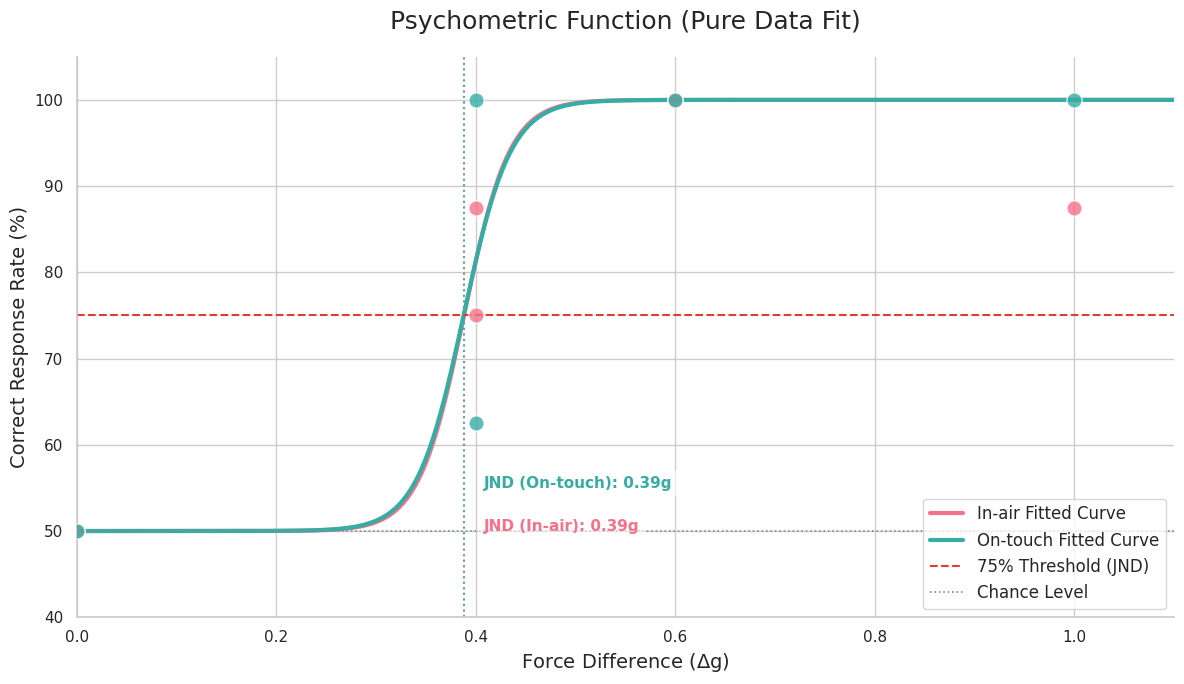

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import expit

# 1. 데이터 로드 및 통합
file_names = ['P1_ForceDiscrimination.csv', 'P2_ForceDiscrimination.csv']
data_list = []

for file in file_names:
    try:
        temp_df = pd.read_csv(file)
        data_list.append(temp_df)
    except FileNotFoundError:
        print(f"파일을 찾을 수 없습니다: {file}")

if not data_list:
    print("데이터가 없습니다.")
else:
    df = pd.concat(data_list, ignore_index=True)

    # 정답 판별 로직
    def calculate_correct(row):
        if row['Comparison'] > row['Reference']:
            return 1 if row['ChoseComparison'] == 1 else 0
        elif row['Comparison'] < row['Reference']:
            return 1 if row['ChoseComparison'] == 0 else 0
        else:
            return 0.5

    df['IsCorrect_Num'] = df.apply(calculate_correct, axis=1)
    df['ForceDiff'] = abs(df['Comparison'] - df['Reference'])

    # 2. 로지스틱 모델 정의
    # 가상 데이터를 삭제했으므로, 실제 데이터의 분포에 따라 시작점과 기울기가 결정됩니다.
    def logistic_model(x, k, x0):
        return 0.5 + 0.5 * expit(k * (x - x0))

    # 3. 시각화 설정
    plt.figure(figsize=(12, 7))
    sns.set_theme(style="whitegrid")

    available_conditions = df['Condition'].unique()
    colors = sns.color_palette("husl", len(available_conditions))
    x_smooth = np.linspace(0, max(df['ForceDiff']) * 1.1, 300)

    for i, cond in enumerate(available_conditions):
        cond_data = df[df['Condition'] == cond]
        if cond_data.empty: continue

        # 실제 측정된 데이터 포인트만 그룹화
        fit_data = cond_data.groupby('ForceDiff')['IsCorrect_Num'].mean().reset_index()

        # 가상 데이터(0, 0.5) 삽입 과정을 삭제하고 실제 데이터만 사용
        X_fit = fit_data['ForceDiff'].values
        Y_fit = fit_data['IsCorrect_Num'].values

        try:
            # 커브 피팅 수행
            # 가상 데이터가 없으므로 초기값(p0) 설정을 실제 데이터 범위에 맞게 조정
            popt, _ = curve_fit(logistic_model, X_fit, Y_fit, p0=[10, np.median(X_fit)], bounds=([0, 0], [50, 2.0]))
            k_fit, x0_fit = popt

            # 곡선 그리기
            y_smooth = logistic_model(x_smooth, k_fit, x0_fit) * 100
            plt.plot(x_smooth, y_smooth, color=colors[i], linewidth=3, label=f'{cond} Fitted Curve')

            # 실제 데이터 포인트 표시
            plt.scatter(fit_data['ForceDiff'], fit_data['IsCorrect_Num'] * 100,
                        color=colors[i], s=120, alpha=0.8, edgecolor='white', zorder=5)

            # JND (75% 지점) 표시
            jnd_val = x0_fit
            plt.axvline(jnd_val, color=colors[i], linestyle=':', alpha=0.8)
            plt.text(jnd_val + 0.02, 50 + (i*5), f'JND ({cond}): {jnd_val:.2f}g',
                     color=colors[i], fontsize=11, fontweight='bold',
                     bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

        except Exception as e:
            print(f"{cond} 피팅 실패: {e}")

    # 4. 가이드라인 및 디테일
    plt.axhline(75, color='#E53935', linestyle='--', linewidth=1.5, label='75% Threshold (JND)')
    plt.axhline(50, color='#78909C', linestyle=':', linewidth=1.2, label='Chance Level')

    plt.title('Psychometric Function (Pure Data Fit)', fontsize=18, pad=20)
    plt.xlabel('Force Difference ($\Delta$g)', fontsize=14)
    plt.ylabel('Correct Response Rate (%)', fontsize=14)
    plt.ylim(40, 105)
    plt.xlim(0, max(df['ForceDiff']) + 0.1)
    plt.legend(frameon=True, loc='lower right', fontsize=12)
    sns.despine()

    plt.tight_layout()
    plt.show()

#음의 difference도..

<>:90: SyntaxWarning: invalid escape sequence '\D'
<>:90: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2461/1257603090.py:90: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('Force Difference ($\Delta$g) [Comparison - Reference]', fontsize=14)


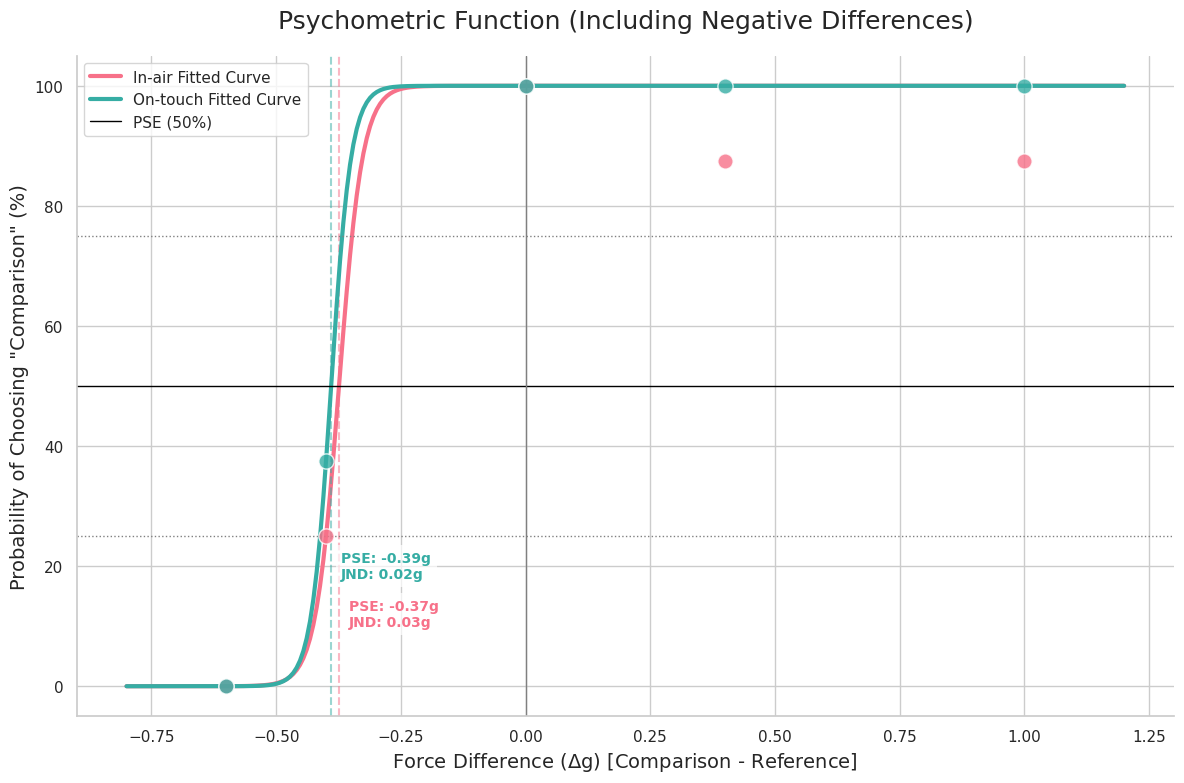

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import expit

# 1. 데이터 로드 및 통합
file_names = ['P1_ForceDiscrimination.csv', 'P2_ForceDiscrimination.csv']
data_list = []

for file in file_names:
    try:
        temp_df = pd.read_csv(file)
        data_list.append(temp_df)
    except FileNotFoundError:
        print(f"파일을 찾을 수 없습니다: {file}")

if not data_list:
    print("데이터가 없습니다.")
else:
    df = pd.concat(data_list, ignore_index=True)

    # --- 핵심 수정 1: Force Difference 계산 (절댓값 제거) ---
    # Comparison - Reference (예: 0.6 - 1.0 = -0.4)
    df['ForceDiff'] = df['Comparison'] - df['Reference']

    # --- 핵심 수정 2: 로지스틱 모델 정의 (0에서 1까지 전체 구간) ---
    # x0: PSE (Point of Subjective Equality, 50% 지점)
    # k: 곡선의 기울기 (민감도)
    def logistic_model(x, k, x0):
        return expit(k * (x - x0))

    # 3. 시각화 설정
    plt.figure(figsize=(12, 8))
    sns.set_theme(style="whitegrid")

    available_conditions = df['Condition'].unique()
    colors = sns.color_palette("husl", len(available_conditions))

    # X축 범위를 마이너스부터 플러스까지 설정
    x_min, x_max = df['ForceDiff'].min(), df['ForceDiff'].max()
    x_smooth = np.linspace(x_min - 0.2, x_max + 0.2, 300)

    for i, cond in enumerate(available_conditions):
        cond_data = df[df['Condition'] == cond]
        if cond_data.empty: continue

        # --- 핵심 수정 3: Y축을 '비교 자극 선택 비율'로 계산 ---
        # ChoseComparison 컬럼의 평균을 구함 (0.0 ~ 1.0)
        fit_data = cond_data.groupby('ForceDiff')['ChoseComparison'].mean().reset_index()

        X_fit = fit_data['ForceDiff'].values
        Y_fit = fit_data['ChoseComparison'].values

        try:
            # 커브 피팅 (초기값 x0는 0 근처로 설정)
            popt, _ = curve_fit(logistic_model, X_fit, Y_fit, p0=[10, 0.0], bounds=([0, -1], [50, 1]))
            k_fit, x0_fit = popt

            # 곡선 및 데이터 포인트 그리기
            y_smooth = logistic_model(x_smooth, k_fit, x0_fit) * 100
            plt.plot(x_smooth, y_smooth, color=colors[i], linewidth=3, label=f'{cond} Fitted Curve')
            plt.scatter(fit_data['ForceDiff'], fit_data['ChoseComparison'] * 100,
                        color=colors[i], s=120, alpha=0.8, edgecolor='white', zorder=5)

            # JND 및 PSE 계산
            # JND는 보통 (75% 지점 - 25% 지점) / 2 로 정의하거나 75% - 50% 차이로 정의함
            pse = x0_fit
            # 75% 지점 x값 찾기: logit(0.75) = k(x - x0) -> x = x0 + logit(0.75)/k
            x75 = x0_fit + (np.log(0.75 / 0.25) / k_fit)
            jnd = x75 - pse

            # 지표 표시
            plt.axvline(pse, color=colors[i], linestyle='--', alpha=0.5)
            plt.text(pse + 0.02, 10 + (i*8), f'PSE: {pse:.2f}g\nJND: {jnd:.2f}g',
                     color=colors[i], fontsize=10, fontweight='bold',
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        except Exception as e:
            print(f"{cond} 피팅 실패: {e}")

    # 4. 가이드라인 및 디테일
    plt.axhline(75, color='gray', linestyle=':', linewidth=1)
    plt.axhline(50, color='black', linestyle='-', linewidth=1, label='PSE (50%)')
    plt.axhline(25, color='gray', linestyle=':', linewidth=1)
    plt.axvline(0, color='gray', linewidth=1) # Reference와 같은 지점

    plt.title('Psychometric Function (Including Negative Differences)', fontsize=18, pad=20)
    plt.xlabel('Force Difference ($\Delta$g) [Comparison - Reference]', fontsize=14)
    plt.ylabel('Probability of Choosing "Comparison" (%)', fontsize=14)
    plt.ylim(-5, 105)
    plt.legend(frameon=True, loc='upper left')
    sns.despine()

    plt.tight_layout()
    plt.show()

In [25]:
# 2. 데이터 전처리
def clean_force(x):
    if isinstance(x, str):
        return float(x.replace('g', ''))
    return x

df['RefVal'] = df['Reference'].apply(clean_force)
df['CompVal'] = df['Comparison'].apply(clean_force)
df['WeberRatio'] = (df['CompVal'] - df['RefVal']) / df['RefVal'] # (ΔF / F)
# IsCorrect가 문자열 'true'/'false'일 경우를 대비해 불리언/정수형 변환
df['IsCorrect'] = df['ChoseComparison'].map({'true': 1, 'false': 0, True: 1, False: 0})

/tmp/ipykernel_2461/3810900702.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='IsCorrect', palette='muted', capsize=.1)


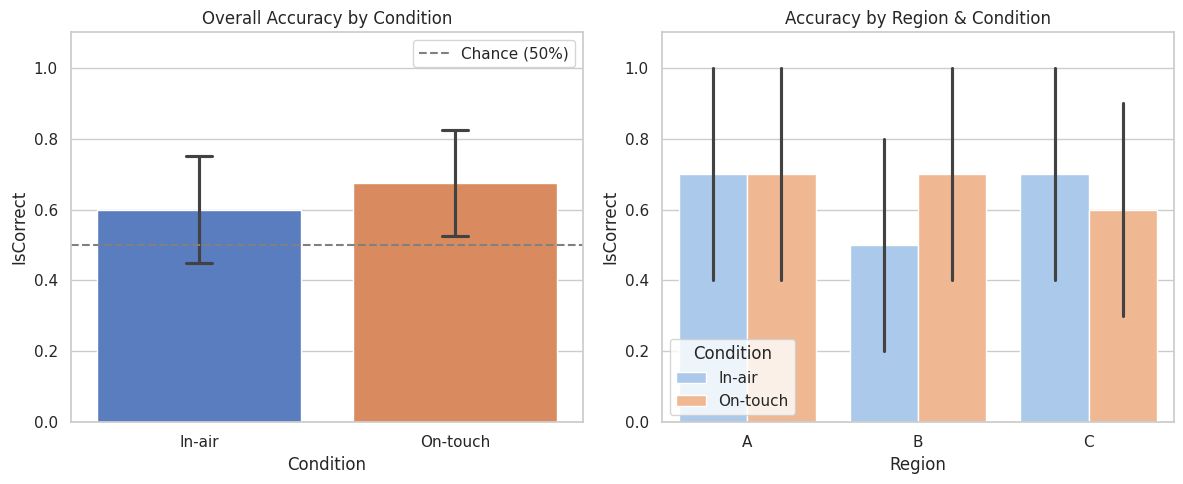

In [26]:
# 3. 주요 지표 시각화 (Accuracy)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# (왼쪽) 조건별 정확도
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='Condition', y='IsCorrect', palette='muted', capsize=.1)
plt.axhline(0.5, ls='--', color='gray', label='Chance (50%)')
plt.title('Overall Accuracy by Condition')
plt.ylim(0, 1.1)
plt.legend()

# (오른쪽) 구역(Region) 및 조건별 정확도
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='Region', y='IsCorrect', hue='Condition', order=['A', 'B', 'C'], palette='pastel')
plt.title('Accuracy by Region & Condition')
plt.ylim(0, 1.1)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2461/2863497069.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='Condition', y='ChoseComparison',


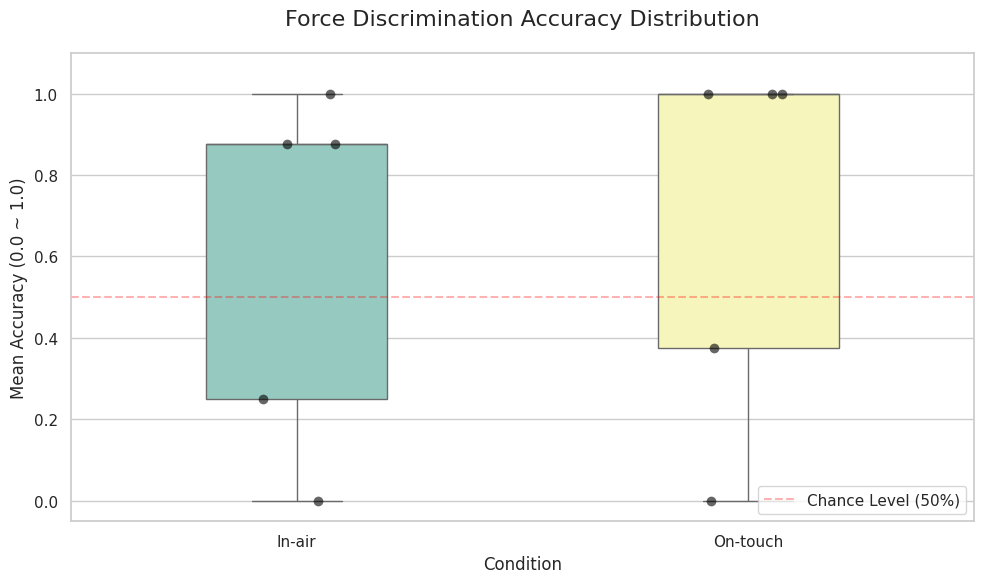

In [27]:
if data_list:
    df_merged = pd.concat(data_list, ignore_index=True)

    # 2. 박스플롯을 위한 데이터 가공
    # 각 조건(Condition) 내에서 '자극 쌍(Reference, Comparison)'별 평균 정답률을 계산합니다.
    # 이렇게 해야 0~1 사이의 다양한 정답률 값이 생성되어 '박스'가 그려집니다.
    plot_data = df_merged.groupby(['Condition', 'Reference', 'Comparison'])['ChoseComparison'].mean().reset_index()

    plt.figure(figsize=(10, 6))

    # 3. 박스플롯 (분포 표시)
    sns.boxplot(data=plot_data, x='Condition', y='ChoseComparison',
                palette='Set3', width=0.4, showfliers=False)

    # 4. 스트립플롯 (모든 데이터 포인트를 점으로 표시)
    # 개별 자극 쌍들의 정답률이 점으로 찍힙니다.
    sns.stripplot(data=plot_data, x='Condition', y='ChoseComparison',
                  color='black', size=7, jitter=True, alpha=0.6)

    # 5. 그래프 꾸미기
    plt.title('Force Discrimination Accuracy Distribution', fontsize=16, pad=20)
    plt.ylabel('Mean Accuracy (0.0 ~ 1.0)', fontsize=12)
    plt.xlabel('Condition', fontsize=12)
    plt.axhline(0.5, ls='--', color='red', alpha=0.3, label='Chance Level (50%)') # 무작위 정답선
    plt.ylim(-0.05, 1.1)
    plt.legend(loc='lower right')

    plt.tight_layout()
    plt.show()
else:
    print("분석할 데이터가 없습니다. 파일명을 확인해 주세요.")

#x 축에 페어가 오는 전체 코드 (isCorrect 재배열)



/tmp/ipykernel_2461/2359822349.py:77: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:red'` for the same effect.

  sns.pointplot(


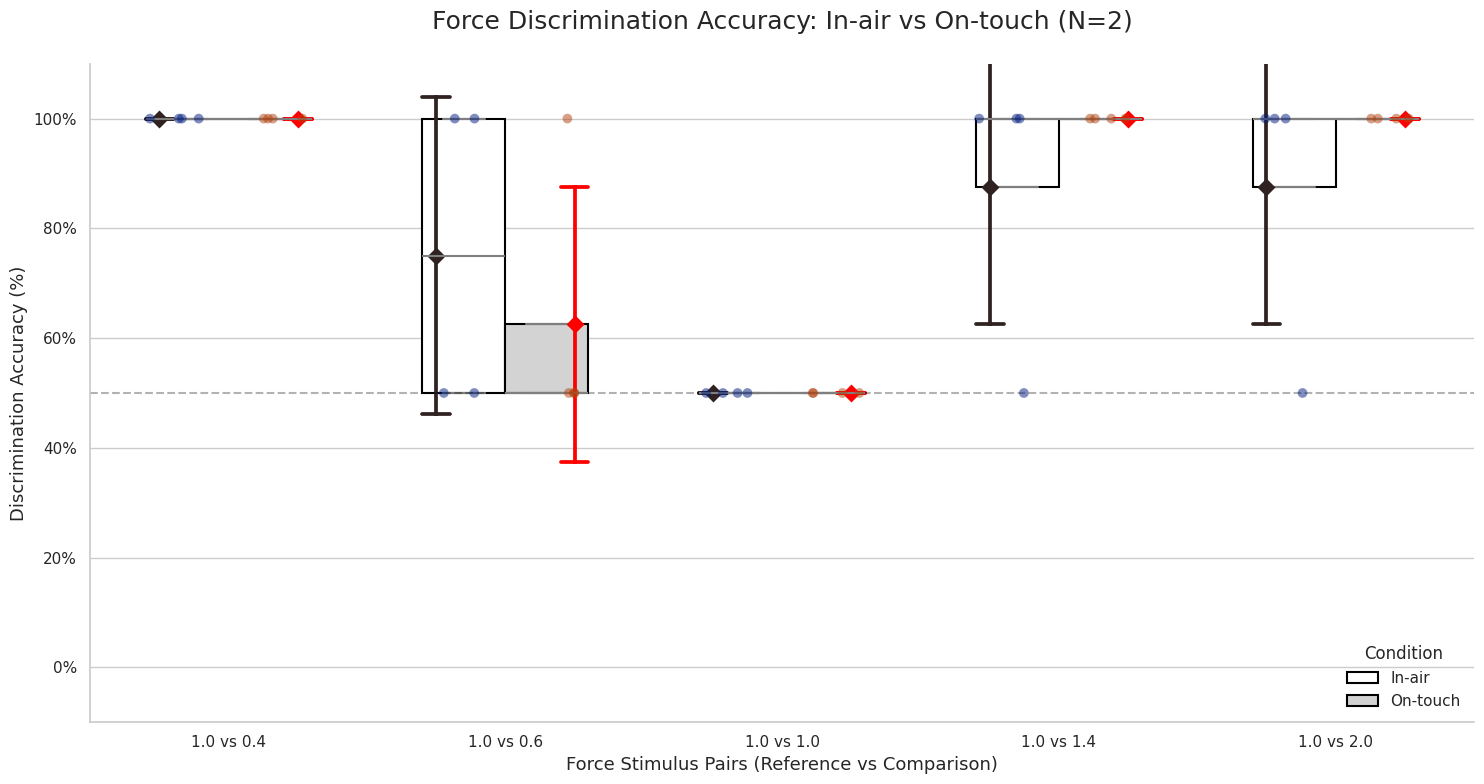


 [조건별/강도별 평균 정답률 (%)] 
Pair       1.0 vs 0.4  1.0 vs 0.6  1.0 vs 1.0  1.0 vs 1.4  1.0 vs 2.0
Condition                                                            
In-air          100.0        75.0        50.0        87.5        87.5
On-touch        100.0        62.5        50.0       100.0       100.0


In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import glob

# 1. 데이터 로드 및 통합
file_pattern = 'P*_ForceDiscrimination.csv'
file_list = glob.glob(file_pattern)

if not file_list:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    df_list = [pd.read_csv(f) for f in file_list]
    df_merged = pd.concat(df_list, ignore_index=True)

    # 2. 전처리 및 정답(IsCorrect) 로직 반영
    df_merged['Ref_num'] = pd.to_numeric(df_merged['Reference'])
    df_merged['Comp_num'] = pd.to_numeric(df_merged['Comparison'])
    df_merged['Pair'] = df_merged.apply(lambda x: f"{x['Ref_num']:.1f} vs {x['Comp_num']:.1f}", axis=1)

    # [수정된 로직] 실제로 더 강한 자극을 선택했는지 판별
    def calc_accuracy(row):
        # 첫 번째 자극이 더 큰 경우 -> 유저가 1번을 골라야 정답
        if row['FirstStim'] > row['SecondStim']:
            return 1 if row['UserChoice'] == 1 else 0
        # 두 번째 자극이 더 큰 경우 -> 유저가 2번을 골라야 정답
        elif row['SecondStim'] > row['FirstStim']:
            return 1 if row['UserChoice'] == 2 else 0
        # 두 자극이 같은 경우 (1.0 vs 1.0) -> 정답 기준이 없으므로 우연(0.5) 처리
        else:
            return 0.5

    df_merged['IsCorrect'] = df_merged.apply(calc_accuracy, axis=1)

    # 3. 분석 그룹화
    # ChoseComparison 대신 IsCorrect의 평균을 계산합니다.
    plot_df = df_merged.groupby(['Condition', 'Pair', 'Comp_num', 'Region'])['IsCorrect'].mean().reset_index()
    plot_df['Accuracy (%)'] = plot_df['IsCorrect'] * 100

    # X축 정렬 순서 (강도 순)
    pair_order = plot_df.sort_values('Comp_num')['Pair'].unique()

    # 4. 시각화 (하나의 플롯에 두 조건 통합)
    plt.figure(figsize=(15, 8))
    sns.set_theme(style="whitegrid")

    # [A] 박스플롯
    sns.boxplot(
        data=plot_df,
        x='Pair',
        y='Accuracy (%)',
        hue='Condition',
        order=pair_order,
        palette=['#FFFFFF', '#D3D3D3'],
        width=0.6,
        linewidth=1.5,
        fliersize=0,
        boxprops={'edgecolor': 'black'}
    )

    # [B] 스트립플롯
    sns.stripplot(
        data=plot_df,
        x='Pair',
        y='Accuracy (%)',
        hue='Condition',
        order=pair_order,
        dodge=True,
        palette='dark',
        size=7,
        alpha=0.5,
        jitter=0.2
    )

    # [C] 에러바 추가 (평균 및 표준편차)
    sns.pointplot(
        data=plot_df,
        x='Pair',
        y='Accuracy (%)',
        hue='Condition',
        order=pair_order,
        dodge=0.5,
        color='red',
        errorbar='sd',
        markers='D',
        linestyle='none',
        capsize=.1
    )

    # 그래프 레이아웃 설정
    num_subjects = df_merged['Subject'].nunique()
    plt.title(f'Force Discrimination Accuracy: In-air vs On-touch (N={num_subjects})', fontsize=18, pad=25)
    plt.ylabel('Discrimination Accuracy (%)', fontsize=13)
    plt.xlabel('Force Stimulus Pairs (Reference vs Comparison)', fontsize=13)

    # 가이드라인 (50% 기회 수준)
    plt.axhline(50, ls='--', color='black', alpha=0.3, label='Chance (50%)')
    plt.ylim(-10, 110)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())

    # 범례 정리
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles[0:2], labels[0:2], title='Condition', frameon=False, loc='lower right')

    sns.despine()
    plt.tight_layout()
    plt.show()

    # 5. 통계 요약표 출력
    print("\n" + "="*50)
    print(" [조건별/강도별 평균 정답률 (%)] ")
    print("="*50)
    summary = plot_df.groupby(['Condition', 'Pair'])['Accuracy (%)'].mean().unstack()
    print(summary)

<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2461/2326878783.py:9: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('Weber Ratio ($\Delta F / F_{ref}$)')


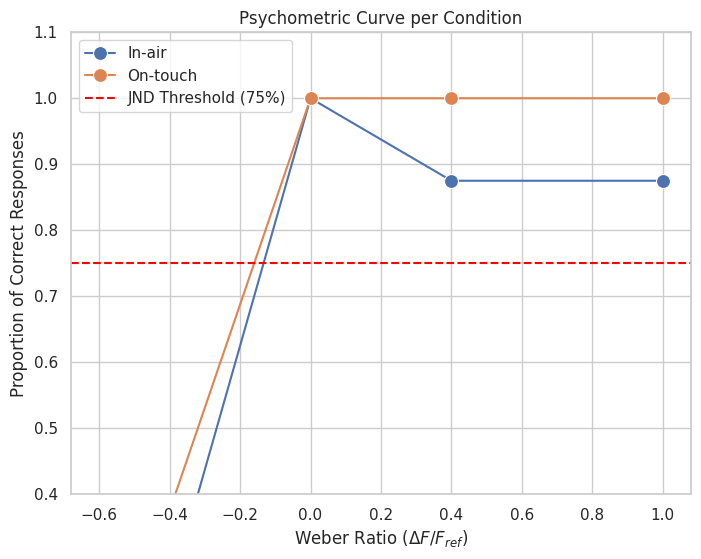


[분석 결과 요약]
 - In-air 조건의 Weber Fraction (K): 약 -0.133
 - On-touch 조건의 Weber Fraction (K): 약 -0.160


In [30]:
# 4. Psychometric Curve (Weber Fraction 추정용)
# Weber Ratio(ΔF/F)에 따른 정답률 계산
psychometric_data = df.groupby(['Condition', 'WeberRatio'])['IsCorrect'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.lineplot(data=psychometric_data, x='WeberRatio', y='IsCorrect', hue='Condition', marker='o', markersize=10)
plt.axhline(0.75, color='red', linestyle='--', label='JND Threshold (75%)')
plt.title('Psychometric Curve per Condition')
plt.xlabel('Weber Ratio ($\Delta F / F_{ref}$)')
plt.ylabel('Proportion of Correct Responses')
plt.ylim(0.4, 1.1)
plt.legend()
plt.show()

# 5. Weber Fraction (K) 결과 출력
print("\n[분석 결과 요약]")
for cond in df['Condition'].unique():
    cond_df = psychometric_data[psychometric_data['Condition'] == cond].sort_values('WeberRatio')
    if len(cond_df) >= 2:
        # 선형 보간을 통한 75% 정답률 지점(Weber Fraction) 계산
        k_est = np.interp(0.75, cond_df['IsCorrect'], cond_df['WeberRatio'])
        print(f" - {cond} 조건의 Weber Fraction (K): 약 {k_est:.3f}")
    else:
        print(f" - {cond} 조건: 데이터 포인트가 부족하여 K 추정 불가")